In [ ]:
!pip install tensorflow
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
import numpy as np
from collections import Counter
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import torch
from torchvision import transforms
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd
import torch.optim as optim
import os
import zipfile
from pathlib import Path
import requests

# torchinfo
!pip install torchinfo
from torchinfo import summary
from torch.utils.data import TensorDataset, DataLoader, Dataset
from tqdm.auto import tqdm
from PIL import Image

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


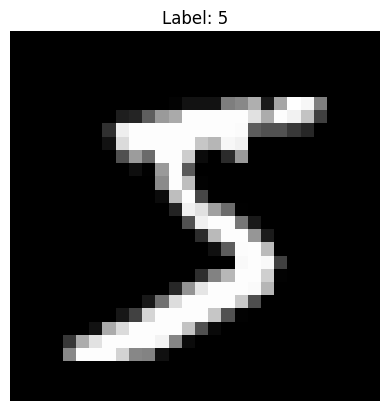

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

plt.imshow(x_train[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()


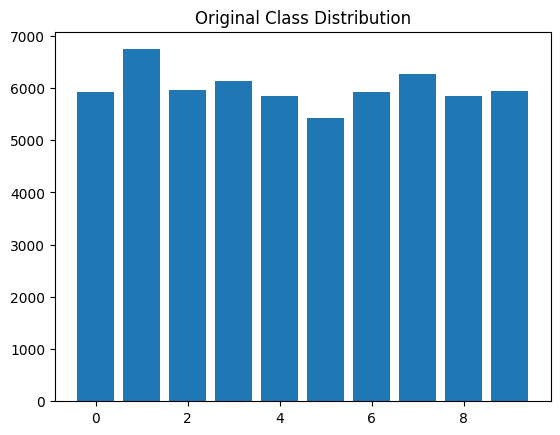

In [ ]:
class_counts = Counter(y_train)
plt.bar(class_counts.keys(), class_counts.values())
plt.title("Original Class Distribution")
plt.show()

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=(0.8, 1.2),
    fill_mode='nearest'
)

In [ ]:
target_per_class = max(class_counts.values())

X_balanced = []
y_balanced = []

print("\n🔹 Creating balanced dataset...")

for digit in range(10):
    digit_images = x_train[y_train == digit]
    count = len(digit_images)

    if count < target_per_class:
        extra_needed = target_per_class - count
        print(f"Digit {digit}: needs {extra_needed} more images")

        digit_images = np.expand_dims(digit_images, -1)
        generator = datagen.flow(digit_images, batch_size=32, shuffle=True)

        new_images = []
        while len(new_images) < extra_needed:
            batch = next(generator)[0]
            new_images.append(batch.squeeze().astype(np.uint8))

        all_images = np.concatenate([digit_images.squeeze(), np.array(new_images)], axis=0)

    else:
        all_images = digit_images

    all_labels = np.full(len(all_images), digit)

    X_balanced.append(all_images)
    y_balanced.append(all_labels)

x_train_bal = np.concatenate(X_balanced)
y_train_bal = np.concatenate(y_balanced)

print("\n✅ Dataset balanced successfully!")
print("New training data shape:", x_train_bal.shape)
print("New labels shape:", y_train_bal.shape)



🔹 Creating balanced dataset...
Digit 0: needs 819 more images
Digit 2: needs 784 more images
Digit 3: needs 611 more images
Digit 4: needs 900 more images
Digit 5: needs 1321 more images
Digit 6: needs 824 more images
Digit 7: needs 477 more images
Digit 8: needs 891 more images
Digit 9: needs 793 more images

✅ Dataset balanced successfully!
New training data shape: (67420, 28, 28)
New labels shape: (67420,)


Balanced class counts: Counter({np.int64(0): 6742, np.int64(1): 6742, np.int64(2): 6742, np.int64(3): 6742, np.int64(4): 6742, np.int64(5): 6742, np.int64(6): 6742, np.int64(7): 6742, np.int64(8): 6742, np.int64(9): 6742})


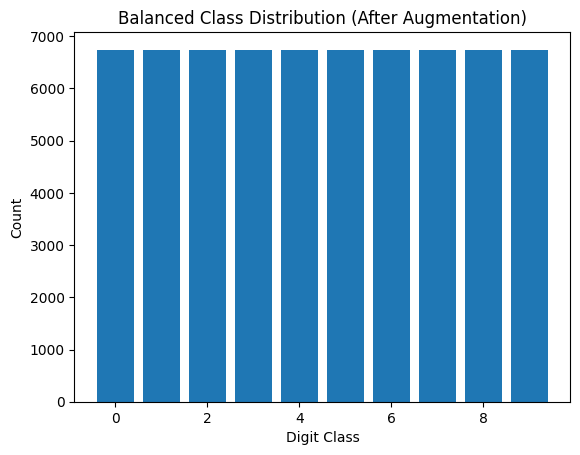

In [ ]:
new_counts = Counter(y_train_bal)
print("Balanced class counts:", new_counts)

plt.bar(new_counts.keys(), new_counts.values())
plt.xlabel("Digit Class")
plt.ylabel("Count")
plt.title("Balanced Class Distribution (After Augmentation)")
plt.show()

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
IMG_SIZE = 299

manual_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [ ]:
weights = torchvision.models.Inception_V3_Weights.DEFAULT
weights

Inception_V3_Weights.IMAGENET1K_V1

In [ ]:
model = torchvision.models.inception_v3(weights=weights).to(device)
model.aux_logits = False
model.AuxLogits = None

Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 142MB/s] 


In [ ]:
summary(
    model,
    input_size=(32, 3, IMG_SIZE, IMG_SIZE),
    col_names=["input_size", "output_size", "num_params", "trainable"]
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
Inception3                               [32, 3, 299, 299]         [32, 1000]                --                        True
├─BasicConv2d: 1-1                       [32, 3, 299, 299]         [32, 32, 149, 149]        --                        True
│    └─Conv2d: 2-1                       [32, 3, 299, 299]         [32, 32, 149, 149]        864                       True
│    └─BatchNorm2d: 2-2                  [32, 32, 149, 149]        [32, 32, 149, 149]        64                        True
├─BasicConv2d: 1-2                       [32, 32, 149, 149]        [32, 32, 147, 147]        --                        True
│    └─Conv2d: 2-3                       [32, 32, 149, 149]        [32, 32, 147, 147]        9,216                     True
│    └─BatchNorm2d: 2-4                  [32, 32, 147, 147]        [32, 32, 147, 147]        64                        True
├─B

# Frozen feature extractor




In [ ]:
for param in model.parameters():
    param.requires_grad = False

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

num_classes = 10
model.fc = nn.Linear(2048, num_classes).to(device)

In [ ]:
summary(
    model,
    input_size=(32, 3, IMG_SIZE, IMG_SIZE),
    col_names=["input_size", "output_size", "num_params", "trainable"]
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
Inception3                               [32, 3, 299, 299]         [32, 10]                  --                        Partial
├─BasicConv2d: 1-1                       [32, 3, 299, 299]         [32, 32, 149, 149]        --                        False
│    └─Conv2d: 2-1                       [32, 3, 299, 299]         [32, 32, 149, 149]        (864)                     False
│    └─BatchNorm2d: 2-2                  [32, 32, 149, 149]        [32, 32, 149, 149]        (64)                      False
├─BasicConv2d: 1-2                       [32, 32, 149, 149]        [32, 32, 147, 147]        --                        False
│    └─Conv2d: 2-3                       [32, 32, 149, 149]        [32, 32, 147, 147]        (9,216)                   False
│    └─BatchNorm2d: 2-4                  [32, 32, 147, 147]        [32, 32, 147, 147]        (64)                      

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

In [ ]:
class MNISTDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx], mode="L").convert("RGB")
        img = self.transform(img)
        return img, self.labels[idx]

train_dataset = MNISTDataset(x_train_bal, y_train_bal, manual_transforms)
test_dataset = MNISTDataset(x_test, y_test, manual_transforms)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
epochs = 5
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(epochs):
    model.train()
    train_loss, correct = 0, 0

    for X, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        X, y = X.to(device), y.to(device)

        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        correct += (y_pred.argmax(1) == y).sum().item()

    train_acc = correct / len(train_dataset)
    train_losses.append(train_loss / len(train_loader))
    train_accuracies.append(train_acc)

    # Evaluation
    model.eval()
    test_loss, test_correct = 0, 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            test_loss += loss_fn(y_pred, y).item()
            test_correct += (y_pred.argmax(1) == y).sum().item()

    test_acc = test_correct / len(test_dataset)
    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Test Loss: {test_losses[-1]:.4f} | Test Acc: {test_acc*100:.2f}%\n")


Epoch 1/5:   0%|          | 0/4214 [00:00<?, ?it/s]

/tmp/ipython-input-242525446.py:11: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode="L").convert("RGB")


Epoch 1/5
Train Loss: 0.7734 | Train Acc: 74.73%
Test Loss: 0.3356 | Test Acc: 89.76%



Epoch 2/5:   0%|          | 0/4214 [00:00<?, ?it/s]

Epoch 2/5
Train Loss: 0.6561 | Train Acc: 78.23%
Test Loss: 0.3040 | Test Acc: 90.20%



...

Epoch 3/5
Train Loss: 0.6675 | Train Acc: 78.17%
Test Loss: 0.2834 | Test Acc: 90.71%



Epoch 4/5:   0%|          | 0/4214 [00:00<?, ?it/s]

Epoch 4/5
Train Loss: 0.6606 | Train Acc: 78.55%
Test Loss: 0.2912 | Test Acc: 90.37%



Epoch 5/5:   0%|          | 0/4214 [00:00<?, ?it/s]

Epoch 5/5
Train Loss: 0.6642 | Train Acc: 78.58%
Test Loss: 0.2689 | Test Acc: 91.24%



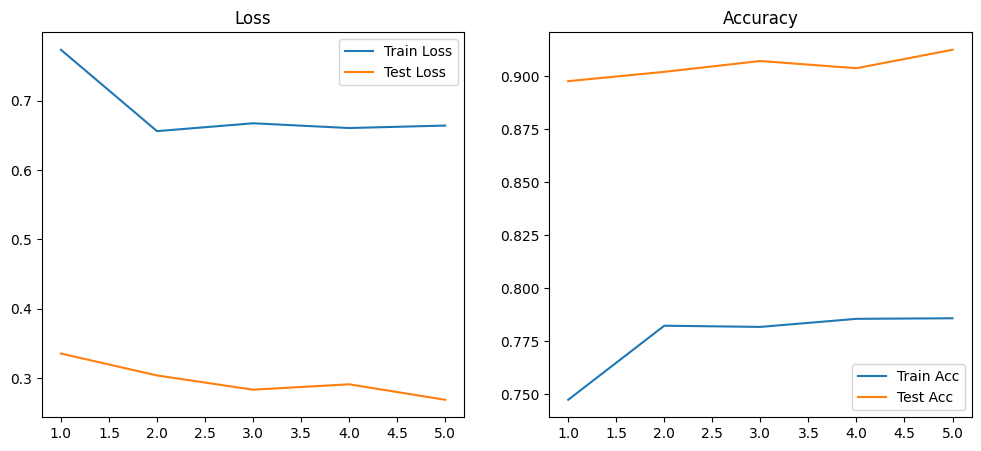

In [ ]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, test_losses, label='Test Loss')
plt.legend()
plt.title("Loss")

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Acc')
plt.plot(epochs_range, test_accuracies, label='Test Acc')
plt.legend()
plt.title("Accuracy")

plt.show()

/tmp/ipython-input-242525446.py:11: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode="L").convert("RGB")


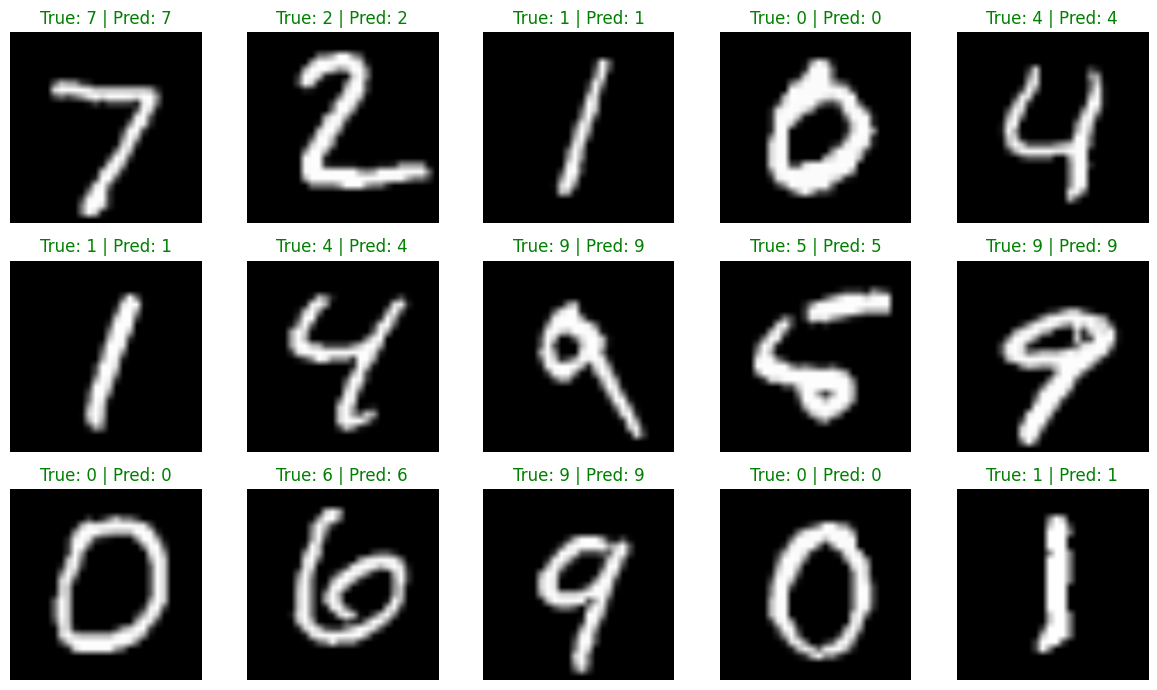

In [ ]:
# Ensure the model is in evaluation mode
model.eval()

# Get a batch of test images
X_batch, y_batch = next(iter(test_loader))
X_batch, y_batch = X_batch.to(device), y_batch.to(device)

# Make predictions
with torch.no_grad():
    y_pred = model(X_batch)
    preds = torch.argmax(y_pred, dim=1)

# Move tensors back to CPU for visualization
X_batch = X_batch.cpu()
y_batch = y_batch.cpu()
preds = preds.cpu()

# Denormalize for visualization
def denormalize(img_tensor):
    """Undo normalization for plotting."""
    img_tensor = img_tensor.clone()
    img_tensor = img_tensor * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img_tensor = img_tensor + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    return torch.clamp(img_tensor, 0, 1)

# Plot a few predictions
fig, axes = plt.subplots(3, 5, figsize=(12, 7))
axes = axes.flatten()

for i, ax in enumerate(axes):
    img = denormalize(X_batch[i]).permute(1, 2, 0)
    true_label = y_batch[i].item()
    pred_label = preds[i].item()

    ax.imshow(img)
    ax.axis("off")
    ax.set_title(f"True: {true_label} | Pred: {pred_label}",
                 color=("green" if true_label == pred_label else "red"))

plt.tight_layout()
plt.show()




# Partial fine tuning

In [ ]:
# Freeze all layers first
for param in model.parameters():
    param.requires_grad = False

# Unfreeze later Inception blocks + classifier
for name, param in model.named_parameters():
    if any(layer in name for layer in ['Mixed_6e', 'Mixed_7a', 'Mixed_7b', 'Mixed_7c', 'fc']):
        param.requires_grad = True

In [ ]:
summary(
    model,
    input_size=(32, 3, 299, 299),
    verbose=0,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"]
)


Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
Inception3 (Inception3)                  [32, 3, 299, 299]    [32, 10]             --                   Partial
├─BasicConv2d (Conv2d_1a_3x3)            [32, 3, 299, 299]    [32, 32, 149, 149]   --                   False
│    └─Conv2d (conv)                     [32, 3, 299, 299]    [32, 32, 149, 149]   (864)                False
│    └─BatchNorm2d (bn)                  [32, 32, 149, 149]   [32, 32, 149, 149]   (64)                 False
├─BasicConv2d (Conv2d_2a_3x3)            [32, 32, 149, 149]   [32, 32, 147, 147]   --                   False
│    └─Conv2d (conv)                     [32, 32, 149, 149]   [32, 32, 147, 147]   (9,216)              False
│    └─BatchNorm2d (bn)                  [32, 32, 147, 147]   [32, 32, 147, 147]   (64)                 False
├─BasicConv2d (Conv2d_2b_3x3)            [32, 32, 147, 147]   [32, 64, 147, 147]   --                   False
│   

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),lr=1e-4)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

epochs = 5

train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(epochs):
    model.train()
    train_loss, correct = 0, 0

    for X, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        correct += (y_pred.argmax(1) == y).sum().item()

    train_acc = correct / len(train_dataset)
    train_losses.append(train_loss / len(train_loader))
    train_accuracies.append(train_acc)

    model.eval()
    test_loss, test_correct = 0, 0

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)

            test_loss += loss_fn(y_pred, y).item()
            test_correct += (y_pred.argmax(1) == y).sum().item()

    test_acc = test_correct / len(test_dataset)
    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Test  Loss: {test_losses[-1]:.4f} | Test  Acc: {test_acc*100:.2f}%\n")

Epoch 1/5:   0%|          | 0/8428 [00:00<?, ?it/s]

/tmp/ipython-input-242525446.py:11: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode="L").convert("RGB")


Epoch 1/5
Train Loss: 0.0969 | Train Acc: 97.40%
Test  Loss: 0.0225 | Test  Acc: 99.28%



Epoch 2/5:   0%|          | 0/8428 [00:00<?, ?it/s]

Epoch 2/5
Train Loss: 0.0351 | Train Acc: 99.01%
Test  Loss: 0.0240 | Test  Acc: 99.29%



...

Epoch 3/5
Train Loss: 0.0215 | Train Acc: 99.40%
Test  Loss: 0.0267 | Test  Acc: 99.29%



Epoch 4/5:   0%|          | 0/8428 [00:00<?, ?it/s]

Epoch 4/5
Train Loss: 0.0168 | Train Acc: 99.54%
Test  Loss: 0.0241 | Test  Acc: 99.28%



Epoch 5/5:   0%|          | 0/8428 [00:00<?, ?it/s]

Epoch 5/5
Train Loss: 0.0122 | Train Acc: 99.63%
Test  Loss: 0.0274 | Test  Acc: 99.40%



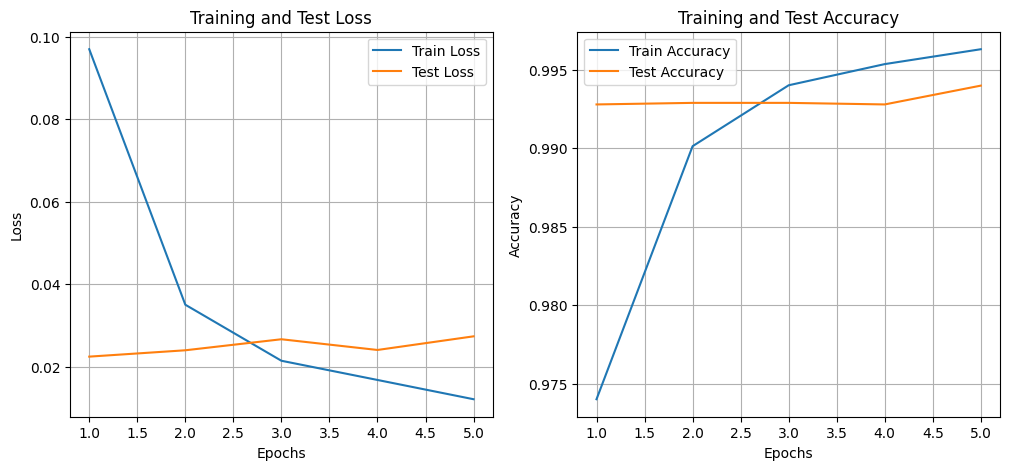

In [ ]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, test_accuracies, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy')
plt.legend()
plt.grid(True)

plt.show()


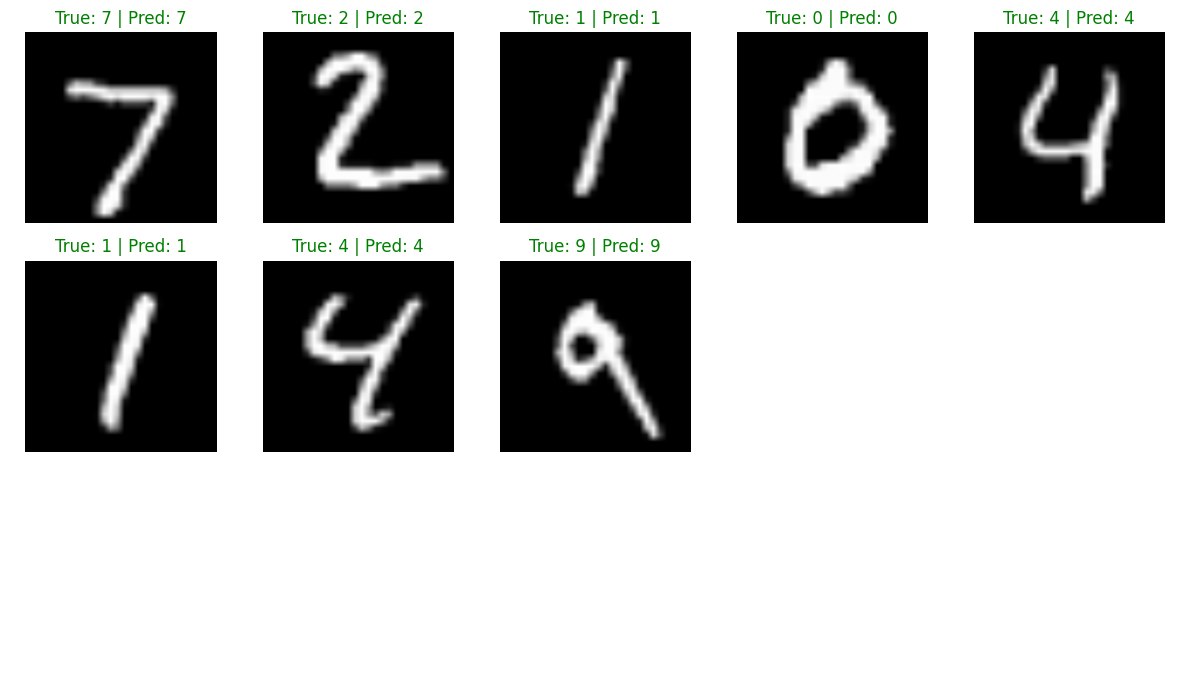

In [ ]:
num_images = min(len(X_batch), 15)

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
axes = axes.flatten()

for i in range(num_images):
    img = denormalize(X_batch[i]).permute(1, 2, 0)
    true_label = y_batch[i].item()
    pred_label = preds[i].item()

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(
        f"True: {true_label} | Pred: {pred_label}",
        color=("green" if true_label == pred_label else "red")
    )

# Turn off unused axes
for j in range(num_images, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# Full Fine Tuning

In [ ]:
for param in model.parameters():
    param.requires_grad = True

model.train()

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

In [ ]:
summary(
    model,
    input_size=(32, 3, 299, 299),
    verbose=0,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    col_width=20,
    row_settings=["var_names"]
)

Layer (type (var_name))                  Input Shape          Output Shape         Param #              Trainable
Inception3 (Inception3)                  [32, 3, 299, 299]    [32, 10]             --                   True
├─BasicConv2d (Conv2d_1a_3x3)            [32, 3, 299, 299]    [32, 32, 149, 149]   --                   True
│    └─Conv2d (conv)                     [32, 3, 299, 299]    [32, 32, 149, 149]   864                  True
│    └─BatchNorm2d (bn)                  [32, 32, 149, 149]   [32, 32, 149, 149]   64                   True
├─BasicConv2d (Conv2d_2a_3x3)            [32, 32, 149, 149]   [32, 32, 147, 147]   --                   True
│    └─Conv2d (conv)                     [32, 32, 149, 149]   [32, 32, 147, 147]   9,216                True
│    └─BatchNorm2d (bn)                  [32, 32, 147, 147]   [32, 32, 147, 147]   64                   True
├─BasicConv2d (Conv2d_2b_3x3)            [32, 32, 147, 147]   [32, 64, 147, 147]   --                   True
│    └─Conv2d 

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=1e-5)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=8, shuffle=False)

epochs = 5
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []

for epoch in range(epochs):
    model.train()
    train_loss, correct = 0, 0

    for X, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        y_pred = model(X)
        loss = loss_fn(y_pred, y)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        train_loss += loss.item()
        correct += (y_pred.argmax(1) == y).sum().item()

    train_acc = correct / len(train_dataset)
    train_losses.append(train_loss / len(train_loader))
    train_accuracies.append(train_acc)

    model.eval()
    test_loss, test_correct = 0, 0

    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            y_pred = model(X)

            test_loss += loss_fn(y_pred, y).item()
            test_correct += (y_pred.argmax(1) == y).sum().item()

    test_acc = test_correct / len(test_dataset)
    test_losses.append(test_loss / len(test_loader))
    test_accuracies.append(test_acc)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_losses[-1]:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"Test  Loss: {test_losses[-1]:.4f} | Test  Acc: {test_acc*100:.2f}%")


Epoch 1/5:   0%|          | 0/8428 [00:00<?, ?it/s]

/tmp/ipython-input-242525446.py:11: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx], mode="L").convert("RGB")



Epoch 1/5
Train Loss: 0.0065 | Train Acc: 99.84%
Test  Loss: 0.0286 | Test  Acc: 99.54%


Epoch 2/5:   0%|          | 0/8428 [00:00<?, ?it/s]


Epoch 2/5
Train Loss: 0.0049 | Train Acc: 99.90%
Test  Loss: 0.0377 | Test  Acc: 99.50%


...


Epoch 3/5
Train Loss: 0.0037 | Train Acc: 99.93%
Test  Loss: 0.0312 | Test  Acc: 99.59%


Epoch 4/5:   0%|          | 0/8428 [00:00<?, ?it/s]


Epoch 4/5
Train Loss: 0.0028 | Train Acc: 99.95%
Test  Loss: 0.0315 | Test  Acc: 99.67%


Epoch 5/5:   0%|          | 0/8428 [00:00<?, ?it/s]


Epoch 5/5
Train Loss: 0.0018 | Train Acc: 99.95%
Test  Loss: 0.0347 | Test  Acc: 99.65%


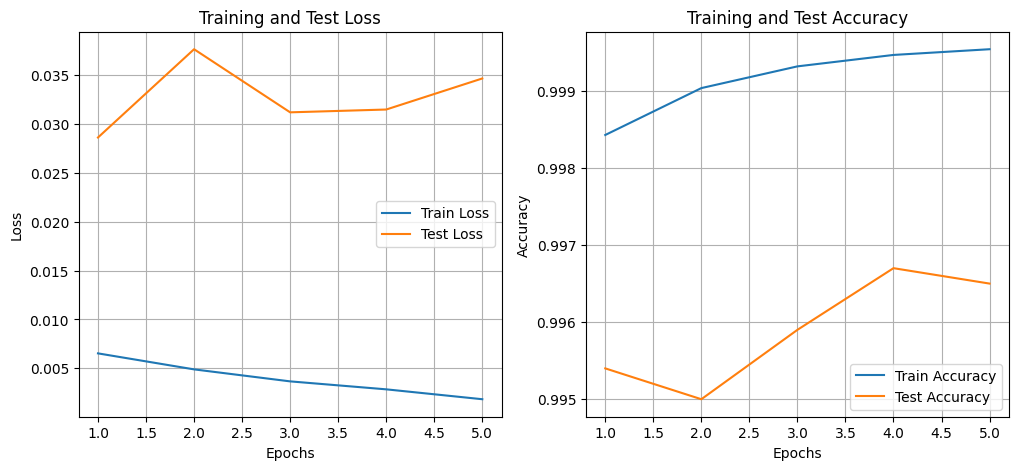

In [ ]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, test_accuracies, label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Test Accuracy')
plt.legend()
plt.grid(True)

plt.show()


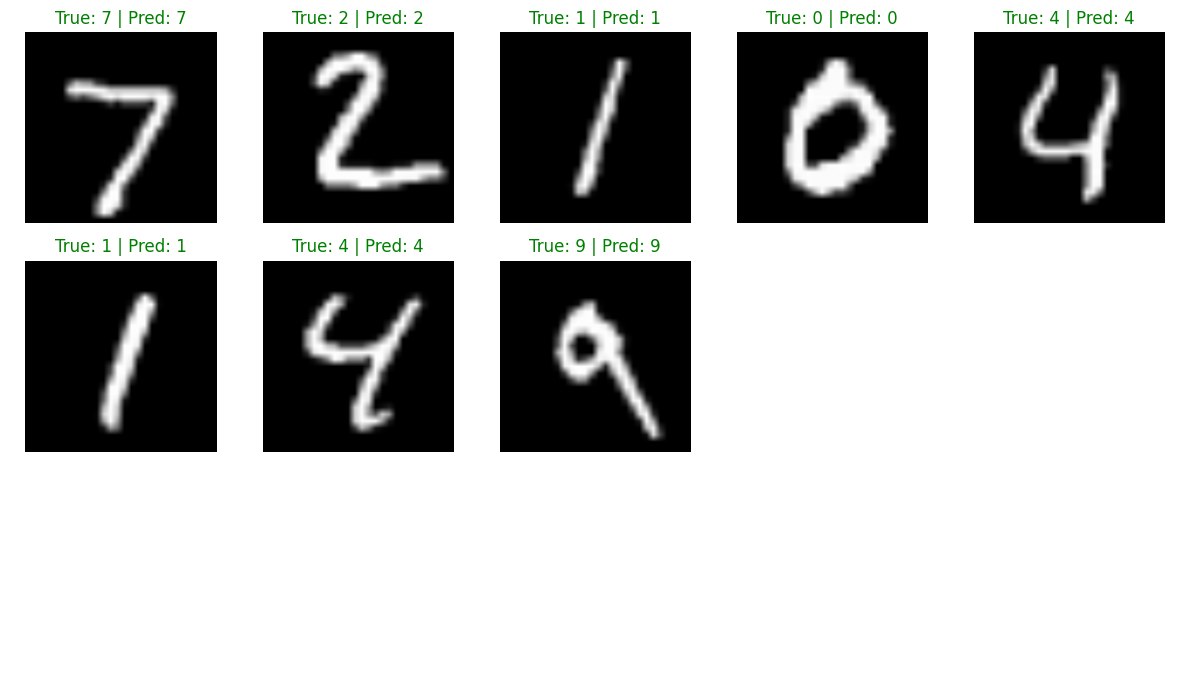

In [ ]:
num_images = min(len(X_batch), 15)

fig, axes = plt.subplots(3, 5, figsize=(12, 7))
axes = axes.flatten()

for i in range(num_images):
    img = denormalize(X_batch[i]).permute(1, 2, 0)
    true_label = y_batch[i].item()
    pred_label = preds[i].item()

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(
        f"True: {true_label} | Pred: {pred_label}",
        color=("green" if true_label == pred_label else "red")
    )

for j in range(num_images, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()